### Importing Libraries

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve
from pathlib import Path



### Data Loading 

In [100]:
data_path = Path.cwd().parent / "datasets" / "diabetes.csv"
df = pd.read_csv(data_path)

In [101]:
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [102]:
df.shape

(70692, 22)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [104]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


### Exploratory Data Analysis

#### ● Data Visualization

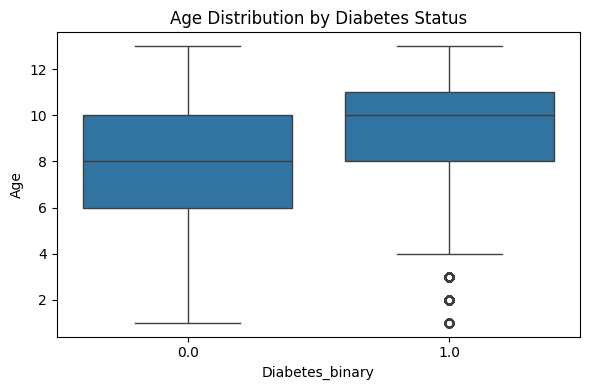

In [105]:
#Age vs Diabetes

'''
Note: 
The 'Age' column is  grouped into 13 levels (_AGEG5YR format)
# 1 = 18-24, 2 = 25-29, ..., 13 = 80 or older
'''

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Diabetes_binary', y='Age')
plt.title('Age Distribution by Diabetes Status')
plt.tight_layout()
plt.show()

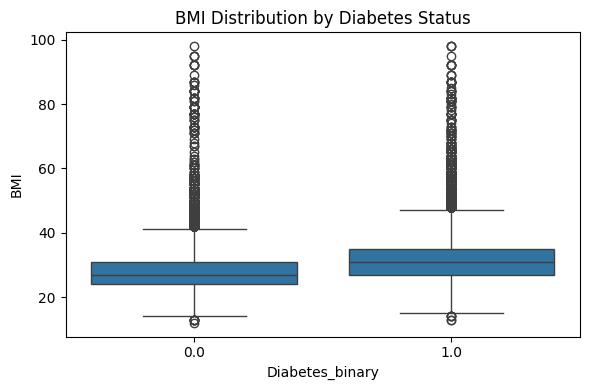

In [106]:
# BMI vs Diabetes

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Diabetes_binary', y='BMI')
plt.title('BMI Distribution by Diabetes Status')
plt.tight_layout()
plt.show()

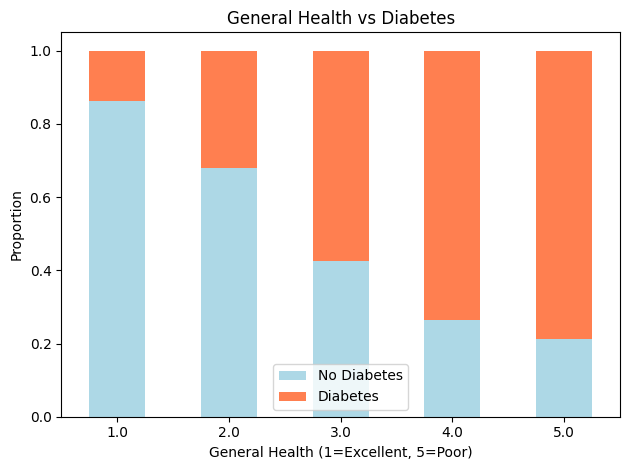

In [107]:
# General Health vs Diabetes

health_diabetes = pd.crosstab(df['GenHlth'], df['Diabetes_binary'], normalize='index')
health_diabetes.plot(kind='bar', stacked=True, color=['lightblue', 'coral'])
plt.title('General Health vs Diabetes')
plt.xlabel('General Health (1=Excellent, 5=Poor)')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

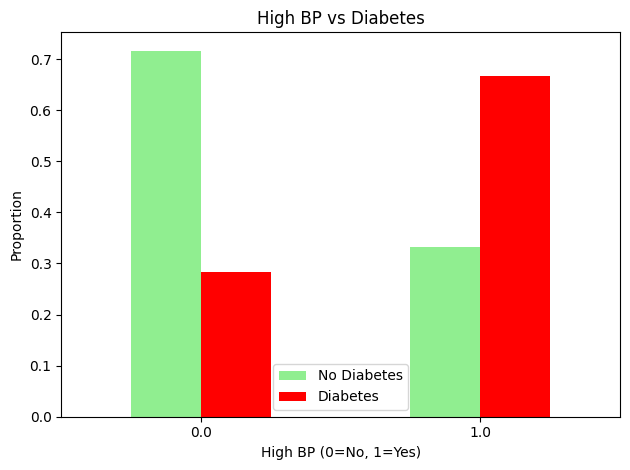

In [108]:
# High BP vs Diabetes

bp_diabetes = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index')
bp_diabetes.plot(kind='bar', color=['lightgreen', 'red'])
plt.title('High BP vs Diabetes')
plt.xlabel('High BP (0=No, 1=Yes)')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

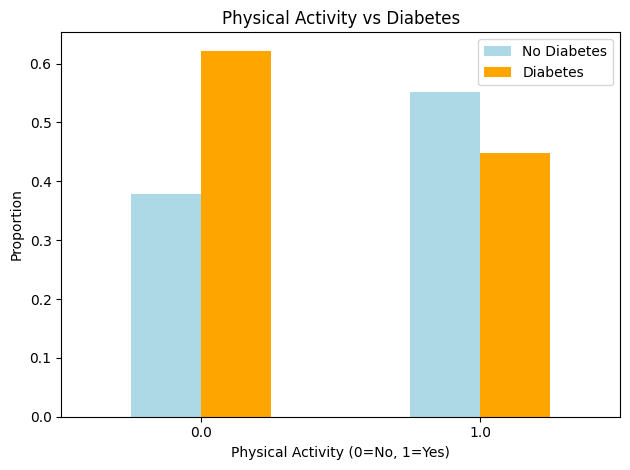

In [109]:
# Physical Activity vs Diabetes

activity_diabetes = pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='index')
activity_diabetes.plot(kind='bar', color=['lightblue', 'orange'])
plt.title('Physical Activity vs Diabetes')
plt.xlabel('Physical Activity (0=No, 1=Yes)')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


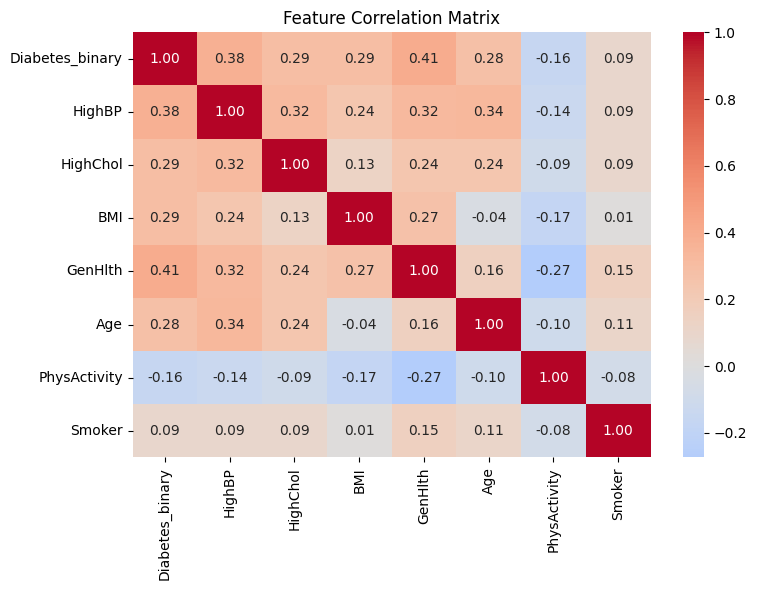

In [110]:
# Correlation Heatmap

key_features = ['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'GenHlth', 'Age', 'PhysActivity', 'Smoker']
corr_matrix = df[key_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

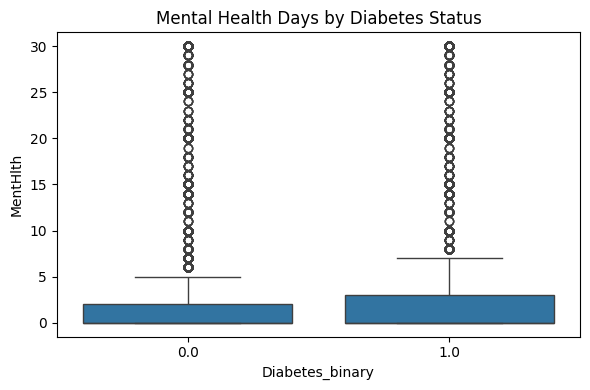

In [111]:
# Mental Health Days

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Diabetes_binary', y='MentHlth')
plt.title('Mental Health Days by Diabetes Status')
plt.tight_layout()
plt.show()

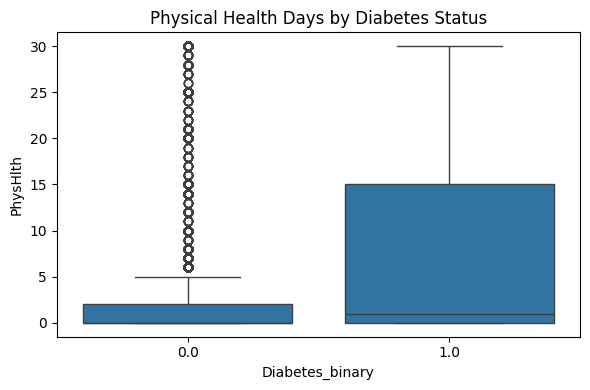

In [112]:
# SECTION 11: Physical Health Days
# ------------------------------
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Diabetes_binary', y='PhysHlth')
plt.title('Physical Health Days by Diabetes Status')
plt.tight_layout()
plt.show()

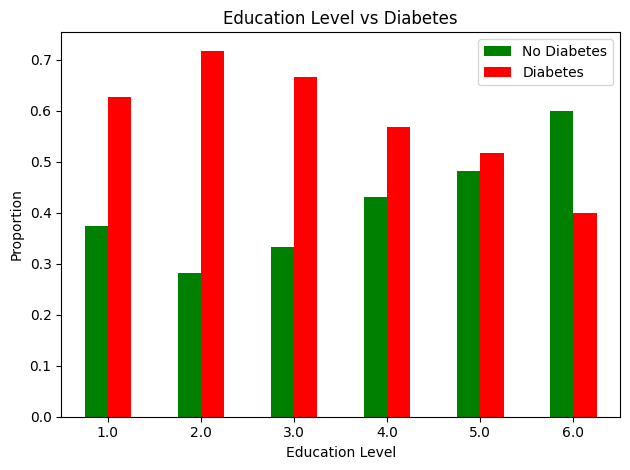

In [113]:
# SECTION 12: Education vs Diabetes
edu_diabetes = pd.crosstab(df['Education'], df['Diabetes_binary'], normalize='index')
edu_diabetes.plot(kind='bar', color=['green', 'red'])
plt.title('Education Level vs Diabetes')
plt.xlabel('Education Level')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

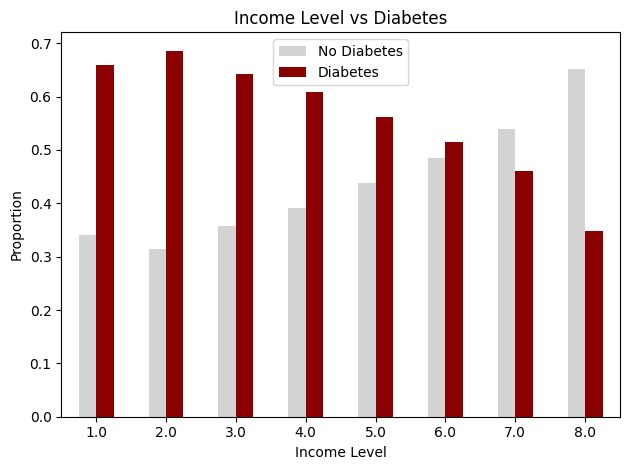

In [114]:
# Income vs Diabetes

income_diabetes = pd.crosstab(df['Income'], df['Diabetes_binary'], normalize='index')
income_diabetes.plot(kind='bar', color=['lightgray', 'darkred'])
plt.title('Income Level vs Diabetes')
plt.xlabel('Income Level')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- key insights


In [115]:
'''
1. People with diabetes tend to report significantly more physical health problems throughout the month compared to non-diabetics, indicating diabetes may be linked to or worsened by other physical conditions.
2. There is a clear negative correlation between general self-rated health and diabetes. People who rate their general health as poor are more likely to be diabetic, showing strong association between perceived overall health and diabetes status.
3. High blood pressure is strongly associated with diabetes. Those with high BP are twice as likely to be diabetic compared to those without it. This suggests high BP may be a major risk factor.
4. Diabetes appears to be inversely related to income — people with lower income levels are more prone to diabetes. This could reflect disparities in access to healthcare, nutrition, and lifestyle factors.

'''

'\n1. People with diabetes tend to report significantly more physical health problems throughout the month compared to non-diabetics, indicating diabetes may be linked to or worsened by other physical conditions.\n2. There is a clear negative correlation between general self-rated health and diabetes. People who rate their general health as poor are more likely to be diabetic, showing strong association between perceived overall health and diabetes status.\n3. High blood pressure is strongly associated with diabetes. Those with high BP are twice as likely to be diabetic compared to those without it. This suggests high BP may be a major risk factor.\n4. Diabetes appears to be inversely related to income — people with lower income levels are more prone to diabetes. This could reflect disparities in access to healthcare, nutrition, and lifestyle factors.\n\n'

### Feature Engineering And Data Preparation

In [116]:

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [117]:
# Identify feature types
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
                  'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                  'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']

continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

print(f"\nBinary features ({len(binary_features)}): {binary_features}")
print(f"Ordinal features ({len(ordinal_features)}): {ordinal_features}")
print(f"Continuous features ({len(continuous_features)}): {continuous_features}")


Binary features (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal features (4): ['GenHlth', 'Age', 'Education', 'Income']
Continuous features (3): ['BMI', 'MentHlth', 'PhysHlth']


In [118]:
# Preprocessing pipeline 
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', StandardScaler(), ordinal_features),
        ('continuous', StandardScaler(), continuous_features),
        ('binary', 'passthrough', binary_features)
    ]
)

#### Model Training and Evaluation

In [119]:
# MODEL BUILDING
base_models = [
    ('logreg', LogisticRegression(max_iter=500, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, eval_metric='logloss')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

In [120]:
meta_learner = LogisticRegression(random_state=42, max_iter=1000)

In [121]:
#Stack classifier model
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1
)


In [122]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stacking_clf)
])

In [123]:
# TRAIN-TEST SPLIT & TRAINING

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal', StandardScaler(),
                                                  ['GenHlth', 'Age',
                                                   'Education', 'Income']),
                                                 ('continuous',
                                                  StandardScaler(),
                                                  ['BMI', 'MentHlth',
                                                   'PhysHlth']),
                                                 ('binary', 'passthrough',
                                                  ['HighBP', 'HighChol',
                                                   'CholCheck', 'Smoker',
                                                   'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'PhysActivity', 'Fruits',
                                                   'Veggies',
                                                   'HvyAlcoholConsump',
                                                   'Any...
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('rf',
                                                 RandomForestClassifier(random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42),
                                    n_jobs=-1, stack_method='predict_proba'))])

In [124]:
# Predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Test Accuracy: {accuracy:.4f}")


 Test Accuracy: 0.7489


In [125]:

auc = roc_auc_score(y_test, y_proba)
print(f" AUC Score: {auc:.4f}")

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))



 AUC Score: 0.8285

 Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.77      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



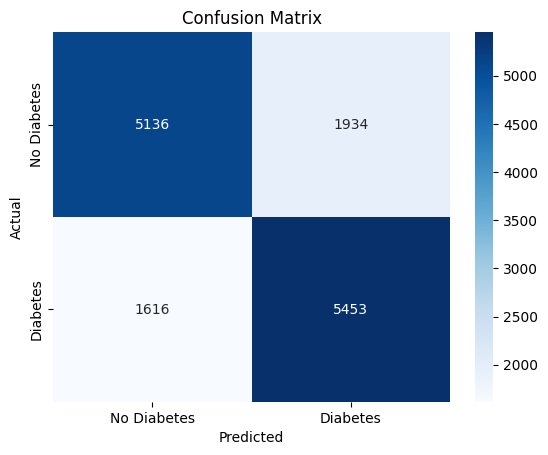

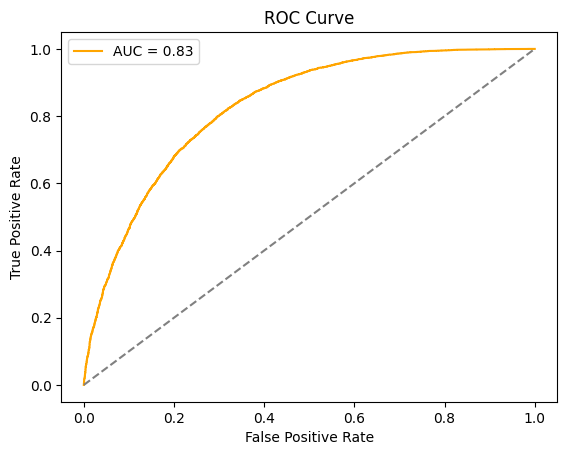

In [126]:
# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### HyperParameter Tuning

In [127]:
param_distributions = {
    'model__xgb__n_estimators': [100, 150, 200],
    'model__xgb__max_depth': [4, 6, 8],
    'model__xgb__learning_rate': [0.05, 0.1, 0.2],

    'model__rf__n_estimators': [100, 150, 200],
    'model__rf__max_depth': [8, 10, 12],
    'model__rf__min_samples_split': [2, 4, 6],

    'model__logreg__C': [0.5, 1.0, 1.5]
}


In [128]:
tuned_model = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [129]:

tuned_model.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('ordinal',
                                                                               StandardScaler(),
                                                                               ['GenHlth',
                                                                                'Age',
                                                                                'Education',
                                                                                'Income']),
                                                                              ('continuous',
                                                                               StandardScaler(),
                                                                               ['BMI',
                                                                                'MentHlth',
                                                                                'PhysHlth']),
                                                                              ('binary',
                                                                               'passthrough',
                                                                               ['HighBP',
                                                                                'HighChol',
                                                                                'CholCheck',
                                                                                'Smoker',
                                                                                'Stroke',
                                                                                'HeartDiseaseorAttack',
                                                                                'PhysActivity',
                                                                                'Fruits',...
                                                                 stack_method='predict_proba'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__logreg__C': [0.5, 1.0, 1.5],
                                        'model__rf__max_depth': [8, 10, 12],
                                        'model__rf__min_samples_split': [2, 4,
                                                                         6],
                                        'model__rf__n_estimators': [100, 150,
                                                                    200],
                                        'model__xgb__learning_rate': [0.05, 0.1,
                                                                      0.2],
                                        'model__xgb__max_depth': [4, 6, 8],
                                        'model__xgb__n_estimators': [100, 150,
                                                                     200]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [130]:
print("Best Parameters:")
print(tuned_model.best_params_)

Best Parameters:
{'model__xgb__n_estimators': 200, 'model__xgb__max_depth': 4, 'model__xgb__learning_rate': 0.05, 'model__rf__n_estimators': 150, 'model__rf__min_samples_split': 6, 'model__rf__max_depth': 12, 'model__logreg__C': 1.5}


In [131]:
best_model = tuned_model.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [132]:
# Accuracy & AUC
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\n Tuned Model Accuracy: {accuracy:.4f}")
print(f" Tuned AUC Score: {auc:.4f}")


 Tuned Model Accuracy: 0.7510
 Tuned AUC Score: 0.8304


In [133]:
# Classification report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))



 Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.72      0.74      7070
         1.0       0.74      0.78      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



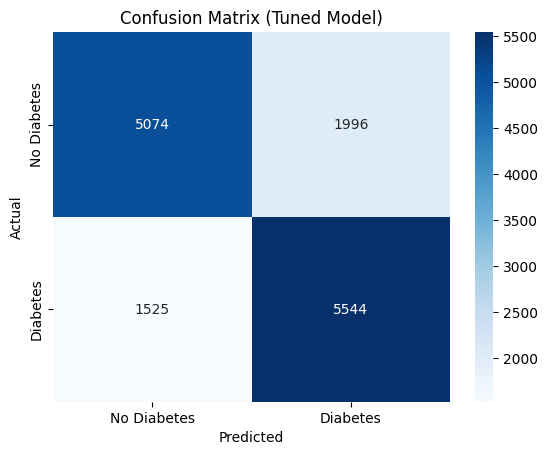

In [134]:
# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Confusion Matrix (Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

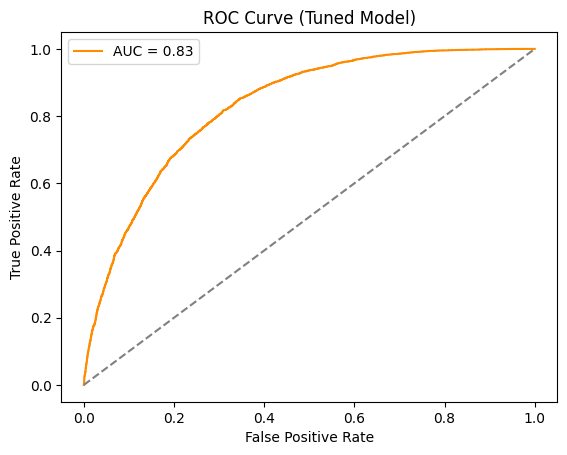

In [135]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve (Tuned Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [136]:
import pickle

with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)  
